# Edge and Ridge Filters

pyclesperanto implements multiple filters for edge-detection and ridge-detection.

> See also [Wikipedia: Edge detection](https://en.wikipedia.org/wiki/Edge_detection) and [Wikipedia: Ridge detection](https://en.wikipedia.org/wiki/Ridge_detection)

In [1]:
import pyclesperanto as cle
from skimage.io import imread
from skimage import data, color
import numpy as np
import matplotlib.pyplot as plt

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

In [2]:
blobs = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze().astype(np.float32))

## Edge Detection Filters

Edge detection filters are based on gradient calculations that identify sharp changes in intensity. pyclesperanto implements several edge detection methods:

- **[Sobel operator](https://en.wikipedia.org/wiki/Sobel_operator)**: Detects edges using directional gradients
- **[Laplace operator](https://en.wikipedia.org/wiki/Discrete_Laplace_operator)**: Detects edges as zero-crossings
- **Laplacian of Gaussian (LoG)**: Also known as the Mexican hat filter
- **Local Variance/Standard Deviation**: Detects areas of high variation

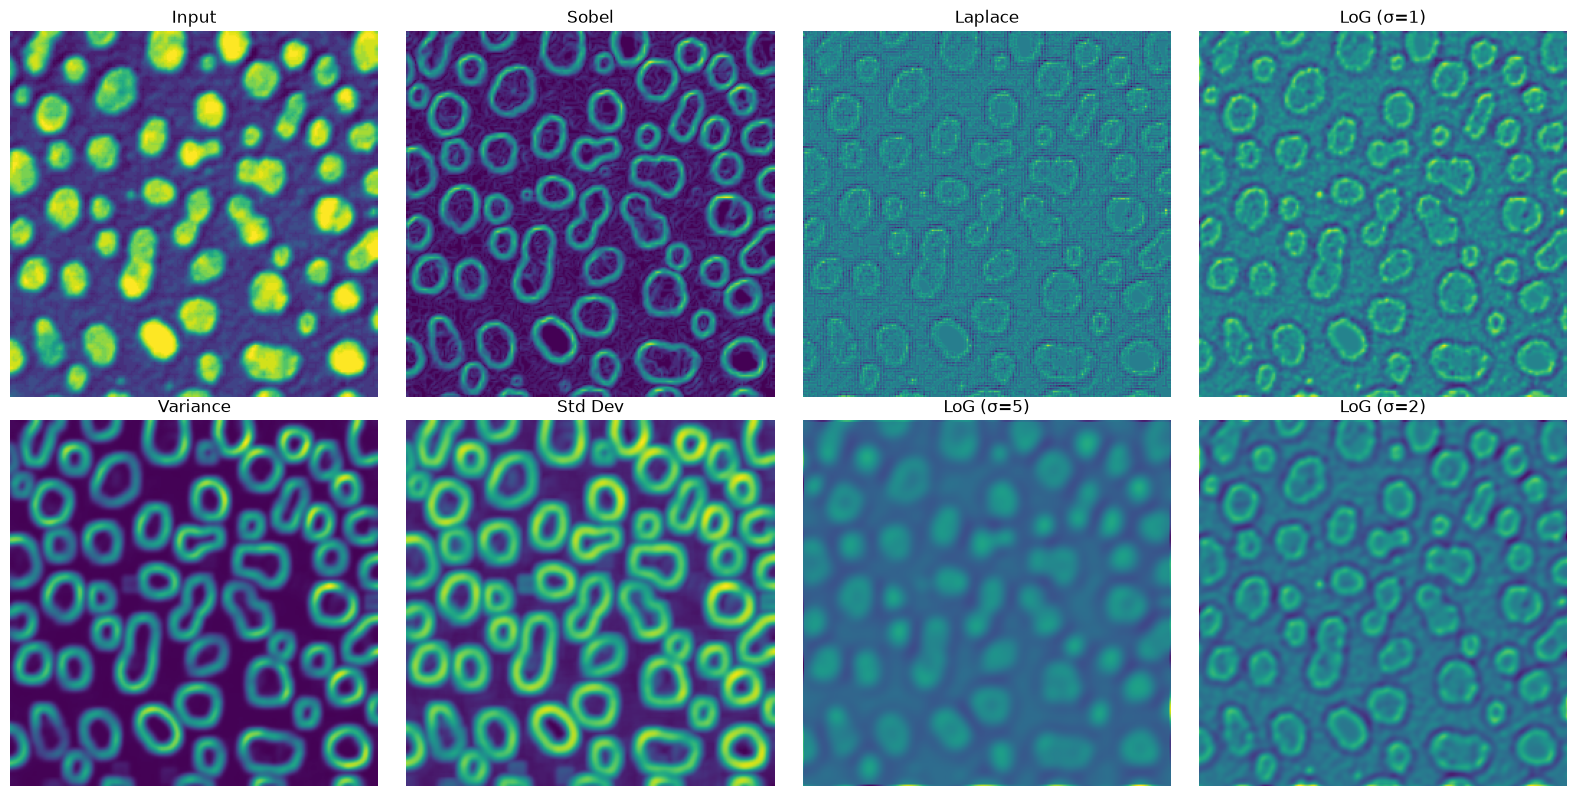

In [3]:
blobs_sobel = cle.sobel(blobs)
blobs_laplace = cle.laplace(blobs)
blobs_log_1 = cle.laplace(cle.gaussian_blur(blobs, sigma_x=1, sigma_y=1))
blobs_log_2 = cle.laplace(cle.gaussian_blur(blobs, sigma_x=2, sigma_y=2))
blobs_log_5 = cle.laplace(cle.gaussian_blur(blobs, sigma_x=5, sigma_y=5))
blobs_variance = cle.variance_filter(blobs, radius_x=5, radius_y=5)
blobs_std = cle.standard_deviation(blobs, radius_x=5, radius_y=5)

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
ax = axs.ravel()
ax[0].imshow(blobs)
ax[0].set_title("Input")
ax[1].imshow(blobs_sobel)
ax[1].set_title("Sobel")
ax[2].imshow(blobs_laplace)
ax[2].set_title("Laplace")
ax[3].imshow(blobs_log_1)
ax[3].set_title("LoG (σ=1)")
ax[4].imshow(blobs_variance)
ax[4].set_title("Variance")
ax[5].imshow(blobs_std)
ax[5].set_title("Std Dev")
ax[6].imshow(blobs_log_5)
ax[6].set_title("LoG (σ=5)")
ax[7].imshow(blobs_log_2)
ax[7].set_title("LoG (σ=2)")
for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

## Understanding the Limitations of Edge Detection for Membrane Enhancement

Edge detection filters respond to gradients, making them useful for detecting edges of objects. However, when applied to biological images with membranes, these filters produce unexpected results.

Membranes are defined by two opposite gradient changes in the same direction - what we call a **ridge**. When you apply an edge detection filter to a membrane, you get a **double edge response**, making the output thicker and more complicated.

**By definition:**
- A **strong change of gradient** in a direction is an "edge"
- **Two strong opposite gradient changes** in the same direction is a "ridge"

Let's demonstrate this with a 3D EM image showing membranes:

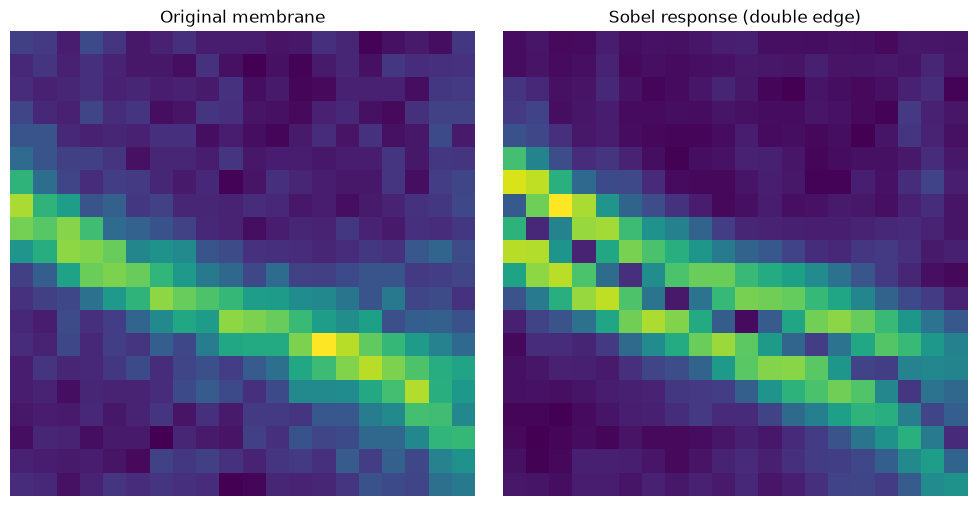

In [4]:
image = cle.push(imread("https://github.com/clEsperanto/clesperanto_example_data/raw/main/EM_C_6_c0.tif"))
image_sobel = cle.sobel(image)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image[60, 125:145, 135:155])
axs[0].set_title("Original membrane")
axs[1].imshow(cle.pull(image_sobel)[60, 125:145, 135:155])
axs[1].set_title("Sobel response (double edge)")
for a in axs:
    a.axis('off')
plt.tight_layout()
plt.show()

Notice that the edges are thicker in the Sobel response. The edge detection filter detects two edges: the increasing signal side of the membrane and the decreasing signal on the opposite side. This double response makes edge detection filters unsuitable for membrane enhancement.

For such tasks, **ridge detection filters are more appropriate**.

## Ridge and Tube Detection

> See also [Ridge detection](https://en.wikipedia.org/wiki/Ridge_detection)

Ridges in 2D, and Tubes in 3D, are structures requiring more advanced filters to detect. Since ridges can be characterized as a double edge, any gradient filtering will produce a double response. Ridge detectors rely instead on the **Hessian matrix eigen values response**.

An iconic filter is the **Sato Filter** [(Sato et. al., 1998)](https://doi.org/10.1016/S1361-8415(98)80009-1) which you can also find in [scikit-image](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.sato) or Fiji under the name [Tubeness](https://imagej.net/plugins/tubeness).

The Sato Filter is a multi-scale filter to detect bright ridges on a dark background. The sigma parameter is directly related to the scale (width) of the ridge to detect.

> Note: the algorithm cumulates the maximum filter response over the sigma range which, for a large range, can introduce noise in the response.

### Sato Filter on Brick Image

A good test case is the `brick` image from the skimage dataset:

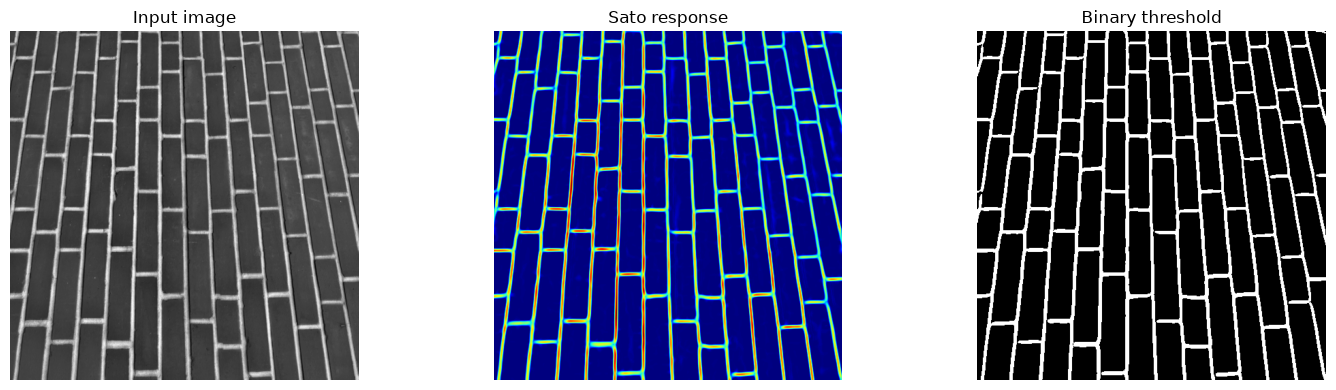

In [5]:
response = cle.sato_filter(data.brick(), sigma_minimum=1, sigma_maximum=4, sigma_step=1)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(data.brick(), cmap="gray")
axs[0].set_title("Input image")
axs[1].imshow(response, cmap="jet")
axs[1].set_title("Sato response")
axs[2].imshow(cle.threshold_otsu(response).get(), cmap="gray")
axs[2].set_title("Binary threshold")
for ax in axs:
    ax.axis('off')
    
plt.tight_layout()
plt.show()

### Sato Filter on Retina Image

The Sato filter works well on vascular structures. Here's an example on the retina dataset:

Pre-processing steps needed:
- Convert RGB image to grayscale
- Invert if needed (Sato detects bright ridges on dark background)

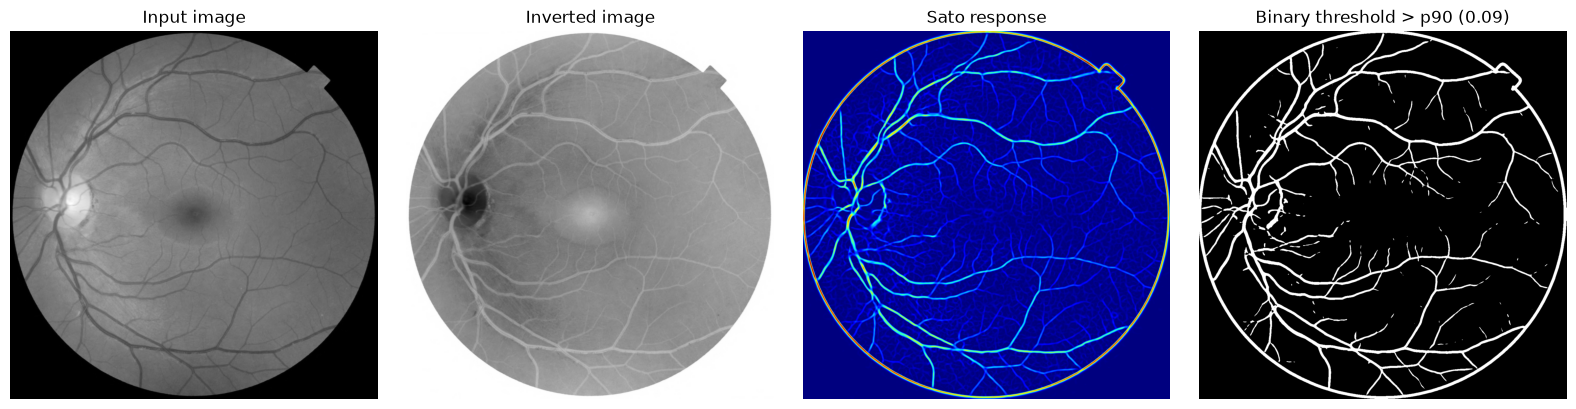

In [14]:
image = color.rgb2gray(data.retina())
inverted = -image
response = cle.sato_filter(inverted, sigma_minimum=0.5, sigma_maximum=5, sigma_step=0.5)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Input image")
axs[1].imshow(inverted, cmap="gray")
axs[1].set_title("Inverted image")
axs[2].imshow(response, cmap="jet")
axs[2].set_title("Sato response")
axs[3].imshow(cle.greater_or_equal_constant(response, scalar=np.percentile(response, 90)).get(), cmap="gray")
axs[3].set_title("Binary threshold > p90 ({:.2f})".format(np.percentile(response, 90)))
for ax in axs:
    ax.axis('off')
    
plt.tight_layout()
plt.show()

### 3D Images and Tube Detection

Ridges in 3D transform into tube structures. The Sato filter can detect tube-shaped structures like filaments or microtubules, especially in low contrast contexts.

> **Important:** Unlike most pyclesperanto filters, the Sato filter applies sigma isometrically (same value in all dimensions). For anisotropic images, pre-process to correct for anisotropy. See the [3D segmentation example](./segmentation_3d.ipynb) for more information.

## Summary

| Filter Type | Method | Best For |
|---|---|---|
| **Edge Detection** | Gradient-based | Sharp intensity changes, object boundaries |
| (Sobel, Laplace, LoG, Variance, Std Dev) | | |
| **Ridge Detection** | Hessian-based | Ridges (2D), Tubes (3D), membranes, filaments |
| (Sato Filter) | | |

Choose the appropriate filter based on the structure you want to detect in your image.

You can also expore lower filtering to build your own or extract lower descriptor using `cle.gradient_x()` (and `y`, `z`) and `cle.hessian_eigenvalues()` operations

Cheers, and have fun with these filters!